# 05 Final Results and Error Analysis

## 1. Goal

A report-style summary: the final model, how it compares to the baseline and the other experiments,
and an error analysis. Everything is loaded from the saved result tables, no training or decoding
happens here, so this notebook just regenerates the tables and plots.

## 2. Load the saved results

We load every saved result table that this notebook presents.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.makedirs("outputs/figures", exist_ok=True)

final = pd.read_csv("outputs/tables/final_model_decoding_result.csv").iloc[0]
candidates = pd.read_csv("outputs/tables/final_decoding_candidates_full_test.csv")
training = pd.read_csv("outputs/tables/training_comparison.csv")
baseline = pd.read_csv("outputs/tables/baseline_results.csv").iloc[0]
print("loaded final result, candidates, training comparison and baseline")

loaded final result, candidates, training comparison and baseline


## 3. Final model summary

A short summary table of the final model.

In [2]:
pd.DataFrame([{
    "final model": final["final_model"],
    "decoding": final["decoding"],
    "test examples": int(final["test_examples"]),
    "BLEU": final["bleu"],
    "chrF++": final["chrf_pp"],
    "repetition %": final["rep_pct"],
}])

,final model,decoding,test examples,BLEU,chrF++,repetition %
0,Exp 2: weight decay 1e-4,beam10 lp1.2 nr3,8491,19.9069,42.2428,4.6


## 4. Final model vs dictionary baseline (full test)

The final model next to the dictionary baseline on the full test.

In [3]:
master = candidates.rename(columns={"experiment": "system", "config": "decoding"})[
    ["system", "decoding", "bleu", "chrf_pp", "rep_pct"]].copy()
master = pd.concat([master, pd.DataFrame([{
    "system": "dictionary baseline", "decoding": "position dictionary",
    "bleu": baseline["bleu"], "chrf_pp": baseline["chrf_pp"], "rep_pct": None}])],
    ignore_index=True).sort_values("bleu", ascending=False).reset_index(drop=True)
master.to_csv("outputs/tables/final_results_master.csv", index=False)
master

,system,decoding,bleu,chrf_pp,rep_pct
0,Exp 2: weight decay 1e-4,beam10 lp1.2 nr3,19.9069,42.2428,4.6
1,Combined: wd+ls+tie+warmup,beam3 lp0.8 nr3,12.3177,32.9156,16.6
2,Exp 5: 3 layers,beam10 lp1.2 nr3,9.7697,30.8195,15.0
3,dictionary baseline,position dictionary,4.7777,25.6503,None


BLEU, chrF++ and repetition compared across the systems.

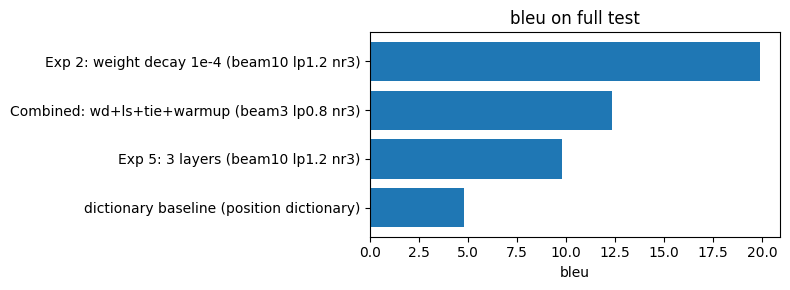

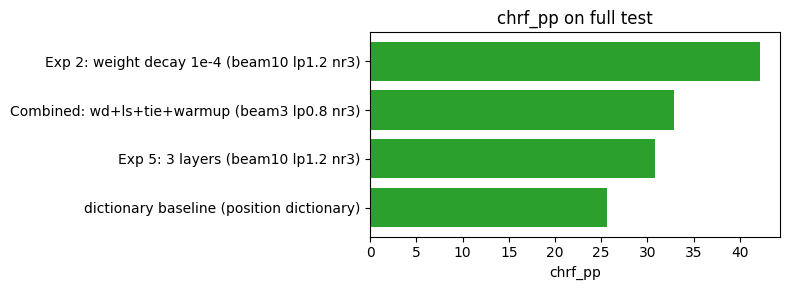

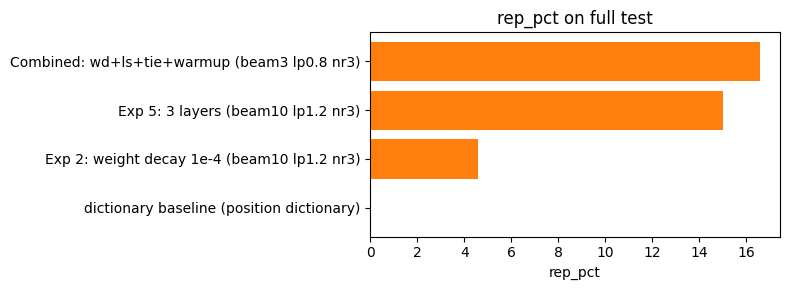

In [4]:
labels = master["system"] + " (" + master["decoding"] + ")"
for metric, color, fname in [("bleu", "tab:blue", "final_bleu_comparison.png"),
                             ("chrf_pp", "tab:green", "final_chrf_comparison.png"),
                             ("rep_pct", "tab:orange", "final_repetition_comparison.png")]:
    d = master.sort_values(metric, na_position="first")
    plt.figure(figsize=(8, 0.5 * len(d) + 1)); plt.barh(labels[d.index], d[metric].fillna(0), color=color)
    plt.xlabel(metric); plt.title(metric + " on full test"); plt.tight_layout()
    plt.savefig("outputs/figures/" + fname); plt.show()

## 5. Training ablation comparison

The full training ablation comparison.

In [5]:
training.sort_values("bleu", ascending=False).reset_index(drop=True)

,category,experiment,bleu,chrf_pp,rep_pct
0,B. Regularization,Exp 2: weight decay 1e-4,18.7879,41.0371,4.8
1,F. Combined,Combined: wd+ls+tie+warmup,12.1496,33.0749,14.5
2,D. Architecture,Exp 5: 3 layers,9.6330,30.4201,13.8
3,A. Training objective,Exp 1: label smoothing 0.1,9.0322,28.5170,13.1
4,D. Architecture,Exp 2: 4+4 layers,8.8564,29.3110,13.4
5,C. Optimization,Exp 1: AdamW wd 1e-4,8.6136,28.2370,14.8
6,E. Data,Exp 4: rare-word aug,8.2235,27.6340,12.6
7,A. Training objective,Exp 2: focal loss,8.1698,27.3715,10.3
8,C. Optimization,Exp 4: curriculum,8.0061,27.5239,11.2
9,Reference,baseline (Adam),7.9885,26.8619,10.1


Training BLEU for every experiment, as a bar chart.

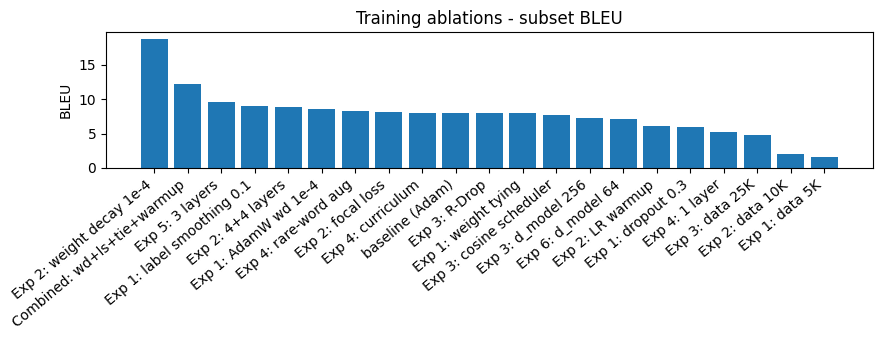

In [6]:
d = training.sort_values("bleu", ascending=False)
plt.figure(figsize=(9, 3.5)); plt.bar(d["experiment"], d["bleu"], color="tab:blue")
plt.title("Training ablations - subset BLEU"); plt.xticks(rotation=40, ha="right"); plt.ylabel("BLEU")
plt.tight_layout(); plt.savefig("outputs/figures/final_training_bleu.png"); plt.show()

### Validation loss across experiments

Validation loss of several experiments, read from their training logs.

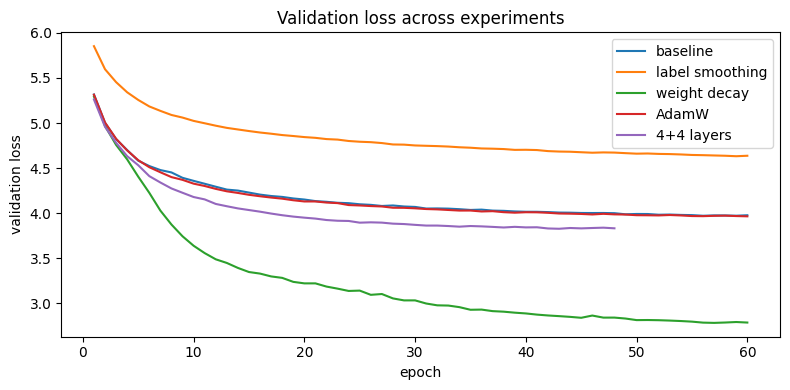

In [7]:
logs = {
    "baseline": "outputs/tables/baseline/training_log.csv",
    "label smoothing": "outputs/tables/A_training_objective/exp1_label_smoothing/training_log.csv",
    "weight decay": "outputs/tables/B_regularization/exp2_weight_decay/training_log.csv",
    "AdamW": "outputs/tables/C_optimization/exp1_adamw/training_log.csv",
    "4+4 layers": "outputs/tables/D_architecture/exp2_layers/training_log.csv",
}
plt.figure(figsize=(8, 4))
for name, path in logs.items():
    if os.path.exists(path):
        h = pd.read_csv(path); plt.plot(h["epoch"], h["val_loss"], label=name)
plt.xlabel("epoch"); plt.ylabel("validation loss"); plt.title("Validation loss across experiments")
plt.legend(); plt.tight_layout(); plt.savefig("outputs/figures/final_val_loss_comparison.png"); plt.show()

## 6. Decoding comparison (full-test candidates)

The decoding candidates evaluated on the full test set.

In [8]:
candidates

,experiment,config,bleu,chrf_pp,rep_pct,n
0,Exp 2: weight decay 1e-4,beam10 lp1.2 nr3,19.9069,42.2428,4.6,8491
1,Combined: wd+ls+tie+warmup,beam3 lp0.8 nr3,12.3177,32.9156,16.6,8491
2,Exp 5: 3 layers,beam10 lp1.2 nr3,9.7697,30.8195,15.0,8491


## 7. Error analysis of the final model

The error categories counted for the final model.

In [9]:
counts = pd.read_csv("outputs/tables/final_error_category_counts.csv")
counts

,error_category,count
0,adequate,870
1,low overlap,66
2,repetition,41
3,over-generation,19
4,severe omission,4


The error categories as a bar chart.

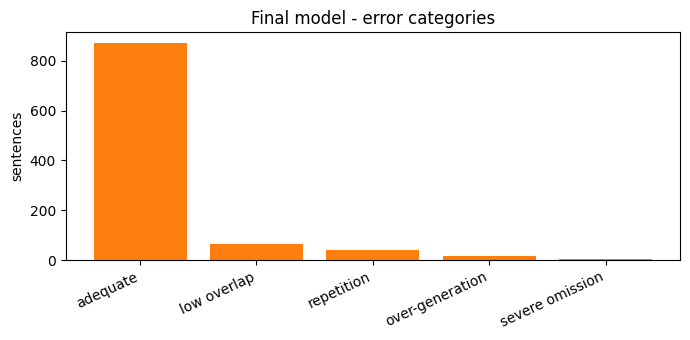

In [10]:
plt.figure(figsize=(7, 3.5)); plt.bar(counts["error_category"], counts["count"], color="tab:orange")
plt.ylabel("sentences"); plt.title("Final model - error categories"); plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.savefig("outputs/figures/final_error_categories.png"); plt.show()

## 8. Example translations

A few example translations from the final model.

In [11]:
preds = pd.read_csv("outputs/examples/final_model_predictions.csv")
preds[["source", "reference", "prediction", "error_category"]].head(8)

,source,reference,prediction,error_category
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","a couple of years ago, here at ted, i've devel...",adequate
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,and the idea is very simple in simplicity. a t...,repetition
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,it should be familiar with the top.,adequate
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","and even though it looks very simple, it's ver...",adequate
4,لذا فقد فكرت بان هذه فكرة مثيرة، وقمت بتضمينها...,"and so, i thought this was an interesting idea...","so i thought that this is an interesting idea,...",adequate
5,وقد كان نجاحاً باهراً.,and it was a huge success.,and it was a huge success.,adequate
6,ومنذ ذلك الحين، قمت بعقد حوالي 70 ورشة عمل للت...,"and since then, i've conducted about 70 design...","and since then, i've lost about 70 holes and d...",repetition
7,اذاً، في العادة، يبدا معظم الناس بتوجيه انفسهم...,"so, normally, most people begin by orienting t...","so, usually, most people start putting themsel...",adequate


## 9. Conclusion

The final system, **weight decay 1e-4 + beam 10, length penalty 1.2, no_repeat_ngram 3**, reaches
**BLEU 19.91 / chrF++ 42.24** on the full test set, far above the dictionary baseline (4.78 / 25.65),
with only ~5% degenerate repetition and ~87% adequate outputs. The single biggest factor was weight
decay during training (verified with a control run in notebook 03); the decoding constraints add a
little more. Remaining errors are mostly low word-overlap on harder sentences. Planned-but-unfinished
experiments are listed honestly in `report_notes/planned_vs_done.md`.